# Define Overcooked style environnement

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from collections import deque


class OvercookedKitchen(gym.Env):
    '''Custom environment for the Overcooked-like kitchen task, designed for reinforcement learning agents. 
    The environment simulates a kitchen where an agent must prepare and deliver dishes by interacting with various elements such as ingredient dispensers, 
    cooking surfaces, chopping boards, and delivery points. The layout of the kitchen is defined by a grid, and the agent receives rewards based on its 
    actions and progress towards completing orders. 
    The environment supports multiple stages of increasing complexity to facilitate curriculum learning.'''
    def __init__(self, layout, stage=5):
        ''' The layout is a list of strings representing the kitchen, where each character corresponds to a type of tile '''
        self.layout = layout
        self.height = len(layout)
        self.width = len(layout[0])
        # We identify the positions of the different elements (cooking surfaces, chopping boards, etc.) in the kitchen based on the layout
        self.cooking_surfaces = [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'P']
        self.stage = stage
        count=1
        self.chopping_boards = {}
        for y, row in enumerate(layout):
            for x, tile in enumerate(row):
                if tile == 'C':
                    self.chopping_boards[(x,y)] = f'chop_board_{count}'
                    count += 1
        self.dish_positions = [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'D']
        self.dispensers = {
            'tomato': [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'T'],
            'steak': [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'S'],
            'bread': [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'B']
        }
        self.delivery = [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'V']

        # Hyperparameters
        self.TIME_TO_CHOP = 3
        self.TIME_TO_COOK = 5
        self.TIME_TO_BURN = 5
        self.MAX_ORDERS = 1
        self.MAX_STEPS = 1000
        self.MAX_ORDER_TIME = 100
        self.action_history = deque(maxlen=10)

        # Actions : 0-3 Movement, 4 Interact, 5 Chop
        self.action_space = spaces.Discrete(6)
        # Observation space : agent_pos (2), agent_dir (4), held_obj (8), pans_state (number of pans * 6), dishes_state (number of dishes * 3), chopping_boards_state (number of chopping boards * 4), ingredient dispensers distances (3), nearest pan distance (1), nearest dish distance (1), nearest chopping board distance (1), time (1)
        obs_size = 0
        # agent position
        obs_size += 2
        # direction one-hot
        obs_size += 4
        # held object encoding
        obs_size += 8
        # pans
        obs_size += len(self.cooking_surfaces) * (2 + 3 + 1)
        # position(2) + status onehot(3) + timer(1)

        # dishes
        obs_size += len(self.dish_positions) * (3)
        #  bread/tomato/steak (3)

        # chopping boards
        obs_size += len(self.chopping_boards) * ( 1 + 3)
        # progress(1) + object encoding(3)

        # ingredient dispensers distances
        obs_size += 3
        # distance nearest pan
        obs_size += 1
        # distance nearest dish
        obs_size += 1
        # distance nearest chopping board
        obs_size += 1
        # time
        obs_size += 1

        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(obs_size,),
            dtype=np.float32
        )

    def reset(self, seed=None):
        '''Reset the environment to the initial state, placing the agent in the starting position and initializing all elements of the kitchen.'''
        super().reset(seed=seed)
        # We reset the timer
        self.step_count = 0
        self.stage = self.stage
        # We place the agent in the middle of the kitchen, facing downwards
        self.agent_pos = (2, 2)
        self.agent_dir = (0, 1) # Regarde vers le bas
        self.held_obj = None
        self.done = False
        self.nb_active_orders = self.MAX_ORDERS
        self.nb_tomato = 0
        self.nb_steak=0
        self.nb_bread = 0
        self.action_history.clear()
        self.objects_on_counters = {} # {(x, y): obj}
        self.pans_state = {}          # {'pan_1': {'location': (x,y), 'status': 'empty', 'timer': 0}}
        self.dishes = {}              # {'dish_1': {'location': (x,y), 'bread': False, 'tomato': False, 'steak': False}}
        self.chopping_boards_state = {}     # {'chop_board_1' : 0}
        self.orders = {}           # {order_id: {'recipe': 'burger', 'timer': 0}}
        
        # Initialize the objects on the counters
        for y, row in enumerate(self.layout):
            for x, tile in enumerate(row):
                if x == 0 or x == self.width-1 or y == 0 or y == self.height-1:
                    self.objects_on_counters[(x, y)] = None # We initialize the perimeter of the kitchen as free of objects

        # Initialize the pans
        for i in range(len(self.cooking_surfaces)):
            pan_pos = self.cooking_surfaces[i]
            self.pans_state[f'pan_{i}'] = {'location': pan_pos, 'status': 'empty', 'timer': 0}
            self.objects_on_counters[pan_pos] = f'pan_{i}' # We consider the pan as an object on the counter when it's not held by the agent, this will allow us to display it and to interact with it more easily
        
        # Initialize the dishes
        for i in range(len(self.dish_positions)):
            dish_pos = self.dish_positions[i]
            self.dishes[f'dish_{i}'] = {'location': dish_pos, 'bread': False, 'tomato': False, 'steak': False}
            self.objects_on_counters[dish_pos] = f'dish_{i}' # We consider the dish as an object on the counter when it's not held by the agent, this will allow us to display it and to interact with it more easily
        
        # Initialize the chopping boards state
        for chop_board in self.chopping_boards.values():
            self.chopping_boards_state[chop_board] = 0 # 0 means empty, otherwise it will represent the chopping progression

        # Stages definition for reverse curriculum learning

        # Stage 1 : The dish already has all the ingredients, the agent just needs to deliver it
        if self.stage == 1:
            self.dishes['dish_0']['bread'] = True
            self.dishes['dish_0']['tomato'] = True
            self.dishes['dish_0']['steak'] = True
            self.nb_bread = 1
            self.nb_tomato = 1
            self.nb_steak = 1
            self.MAX_STEPS = 400

        # Stage 2 : The dish has the bread, the chopped tomato is on the chopping board, the steak is cooking in the pan, the agent needs to pick up the chopped tomato and the steak, put them on the dish and deliver it
        elif self.stage == 2:
            self.dishes['dish_0']['bread'] = True
            self.nb_bread = 1
            chop_pos = list(self.chopping_boards.keys())[0]
            self.objects_on_counters[chop_pos] = 'chopped_tomato'
            self.pans_state['pan_0']['status'] = 'ready'
            self.pans_state['pan_0']['timer'] = self.TIME_TO_COOK
            self.objects_on_counters[self.pans_state['pan_0']['location']] = 'pan_0' # We put the pan with the cooked steak back on the counter
            self.nb_bread = 1
            self.nb_tomato = 1
            self.nb_steak = 1
            self.orders["order_0"] = {'recipe': 'burger', 'timer': 0}
            self.MAX_STEPS = 400

        # Stage 3 : The dish has the bread, the tomato is on the chopping board, the steak is cooked in the pan, the agent needs to chop the tomato, put them on the dish and deliver it
        elif self.stage == 3:
            self.dishes['dish_0']['bread'] = True
            self.nb_bread = 1
            self.pans_state['pan_0']['status'] = 'ready'
            self.pans_state['pan_0']['timer'] = self.TIME_TO_COOK
            self.objects_on_counters[self.pans_state['pan_0']['location']] = 'pan_0' # We put the pan with the cooked steak back on the counter
            self.nb_bread = 1
            self.nb_steak = 1
            self.orders["order_0"] = {'recipe': 'burger', 'timer': 0}

        # Stage 4 (final stage) : The agent has the learning the full task
        elif self.stage == 4:
            return self._get_obs(), {}

        return self._get_obs(), {}

    # Render the kitchen state in the console for debugging purposes
    def render(self):
        '''Render the current state of the kitchen in the console, showing the layout and the positions of the agent, objects, and orders.'''

        grid_copy = [list(row) for row in self.layout]
        # Display the objects on the counters (tomatoes, steaks, bread, ) with their first letter in uppercase
        for (x, y), obj in self.objects_on_counters.items():
            if obj is not None:
                char = obj[0].upper()
                grid_copy[y][x] = char
        
        # Display the ingredients dispensers with their corresponding letters
        for ingredient, positions in self.dispensers.items():
            char = ingredient[0].upper()
            for (x, y) in positions:
                grid_copy[y][x] = char

        # Display the agent with an arrow indicating its direction
        ax, ay = self.agent_pos
        dir_map = {(0, -1): '^', (0, 1): 'v', (-1, 0): '<', (1, 0): '>'}
        grid_copy[ay][ax] = dir_map.get(self.agent_dir, 'A')

        # Indications for debugging purposes
        print("\n" + "="*20)
        for row in grid_copy:
            print(" ".join(row))
        print(f"Hand : {self.held_obj}")
        print(f"Pans : {[(p['location'], p['status'], p['timer']) for p in self.pans_state.values()]}")
        print(f"Dishes : {[(d['location'], d['bread'], d['tomato'], d['steak']) for d in self.dishes.values()]}")
        print(f"Chopping boards : {[(c, self.chopping_boards_state[c]) for c in self.chopping_boards_state]}")
        print(f"Objects on counters : {[(pos, obj) for (pos, obj) in self.objects_on_counters.items() if obj is not None]}")
        print(f"Orders: {len([o for o in self.orders.values() if o['recipe'] != 'empty'])} active")
        if self.orders:
            for oid, order in self.orders.items():
                if order['recipe'] != 'empty':
                    print(f"  {oid}: {order['recipe']} (wait: {order['timer']})")
        print(f"Steps: {self.step_count}/{self.MAX_STEPS}")
        print("="*20)
    
    # Observation vector : encode the state of the kitchen in a vector that will be used as input for the agent
    def _get_obs(self):
        '''Encode the current state of the kitchen into a fixed-size observation vector, including the agent's position and direction, held object, state of pans, dishes, chopping boards, distances to key locations, and time.
        This observation will be used as input for the reinforcement learning agent to make decisions.'''

        obs = []
        ax, ay = self.agent_pos

        # Agent position (normalized)
        obs.append(ax / self.width)
        obs.append(ay / self.height)

        # direction one-hot
        dir_vec = [0,0,0,0]  # up down left right

        if self.agent_dir == (0,-1): dir_vec[0] = 1
        elif self.agent_dir == (0,1): dir_vec[1] = 1
        elif self.agent_dir == (-1,0): dir_vec[2] = 1
        elif self.agent_dir == (1,0): dir_vec[3] = 1

        obs.extend(dir_vec)

        # Held object encoding
        held_encoding = [0]*8
        # [none, tomato, steak, bread, chopped_tomato, burger, pan_empty, pan_ready]

        if self.held_obj is None:
            held_encoding[0] = 1

        elif self.held_obj == "tomato":
            held_encoding[1] = 1

        elif self.held_obj == "steak":
            held_encoding[2] = 1

        elif self.held_obj == "bread":
            held_encoding[3] = 1

        elif self.held_obj == "chopped_tomato":
            held_encoding[4] = 1

        elif self.held_obj == "full_burger":
            held_encoding[5] = 1

        elif "pan" in str(self.held_obj):

            pan = self.pans_state[self.held_obj]

            if pan["status"] == "ready":
                held_encoding[7] = 1
            else:
                held_encoding[6] = 1

        obs.extend(held_encoding)

        # Pans state
        for pan in self.pans_state.values():

            px, py = pan["location"]

            # status
            if pan["status"] == "empty":
                obs.extend([1,0,0])
            elif pan["status"] == "cooking":
                obs.extend([0,1,0])
            else:
                obs.extend([0,0,1])

            # cooking progress
            obs.append(pan["timer"] / self.TIME_TO_COOK)

        # Dish state
        for dish in self.dishes.values():

            dx, dy = dish["location"]

            obs.append(int(dish["bread"]))
            obs.append(int(dish["tomato"]))
            obs.append(int(dish["steak"]))

        # Chopping boards state
        for pos, board_id in self.chopping_boards.items():

            x,y = pos

            obs.append(x / self.width)
            obs.append(y / self.height)

            progress = self.chopping_boards_state[board_id] / self.TIME_TO_CHOP
            obs.append(progress)

            obj = self.objects_on_counters.get(pos)

            board_obj = [0,0,0]

            if obj is None:
                board_obj[0] = 1
            elif obj == "tomato":
                board_obj[1] = 1
            elif obj == "chopped_tomato":
                board_obj[2] = 1

            obs.extend(board_obj)

        #  Distances to ingredient dispensers
        for ingredient in ["tomato","steak","bread"]:

            positions = self.dispensers[ingredient]

            dist = min(abs(ax-x)+abs(ay-y) for x,y in positions)

            obs.append(dist / (self.width + self.height))

        
        # Distance to nearest pan
        pan_dist = min(
            abs(ax-pan["location"][0]) + abs(ay-pan["location"][1])
            for pan in self.pans_state.values()
        )

        obs.append(pan_dist / (self.width + self.height))


        # Distance to nearest dish
        dish_dist = min(
            abs(ax-dish["location"][0]) + abs(ay-dish["location"][1])
            for dish in self.dishes.values()
        )

        obs.append(dish_dist / (self.width + self.height))

        # Distance to nearest chopping board
        chop_dist = min(
            abs(ax - x) + abs(ay - y)
            for x, y in self.chopping_boards.keys()
        )
        obs.append(chop_dist / (self.width + self.height))

        #Time
        obs.append(self.step_count / self.MAX_STEPS)

        return np.array(obs, dtype=np.float32)
    
    def _get_adj_pos(self):
        '''Helper function to get the position adjacent to the agent based on its current direction,
        this will be used for interactions'''
        x, y = self.agent_pos
        dx, dy = self.agent_dir
        return (x + dx, y + dy)

    def step(self, action):
        '''Execute the action, update the state and calculate the reward'''

        reward = -0.002 # Survival reward to encourage agent speed

        ## Cooking progress update (passive update)
        for _, pan in self.pans_state.items():
            if pan['status'] != 'empty' and pan['location'] in self.cooking_surfaces:
                if self.stage >= 4:
                    pan['timer'] += 1
                if pan['timer'] >= self.TIME_TO_COOK:
                    pan['status'] = 'ready'
                    if pan['timer'] > self.TIME_TO_COOK:
                            reward -= 0.001 # Penalty for overcooking, to encourage the agent to pick up the steak once it's ready
                    elif self.stage >= 4:
                        reward += 0.3 # Reward for cooking the steak, to encourage the agent to cook the steak
                if pan['timer'] >= self.TIME_TO_COOK + self.TIME_TO_BURN:
                    pan['status'] = 'empty' # The steak is burned and disappears, reset the pan
                    pan['timer'] = 0
                    if self.stage >= 4:
                        reward -= 0.5 # Additional penalty for burning the steak in stage 4, to further encourage the agent to cook the steak properly
                    else:
                        reward -= 0.3 # Penalty for burning the steak, to encourage the agent to cook the steak properly
        for _, order in self.orders.items():
            if order['recipe'] != 'empty':
                order['timer'] += 1
                if order['timer'] >= self.MAX_ORDER_TIME:
                    reward -= 0 # Penalty for not delivering the order in time, set to 0 for now to encourage exploration, can be increased later to encourage faster deliveries
        
        if action < 4: # MOVEMENT
            move_reward = self._handle_move(action)
            reward += move_reward
        
        elif action == 4: # INTERACT (Take/Place/Cook)
            target_pos = self._get_adj_pos()
            tile = self.layout[target_pos[1]][target_pos[0]]
            if target_pos in self.dispensers['tomato'] and self.held_obj == None: # If it's an ingredient dispenser, agent pick up the ingredient
                self.held_obj = "tomato"
                if self.stage ==3 :
                    reward += 0.5 # Higher reward for picking up the raw tomato in stage 3, to encourage the agent to pick up the tomato and not just move it around
                else:
                    reward += 0.1 # Small reward for picking up a raw ingredient, to encourage the agent to get ingredients and not just move them around
                self.nb_tomato += 1
                if  self.nb_tomato > self.nb_active_orders:
                    if self.stage ==3 :
                        reward -= 0.5 # Higher penalty for picking up more tomatoes than needed in stage 3, to encourage the agent to only pick up the ingredients it needs
                    else : reward -= 0.1 # Penalty for picking up more tomatoes than needed, to encourage the agent to only pick up the ingredients it needs
            elif target_pos in self.dispensers['steak'] and self.held_obj == None:
                self.held_obj = "steak"
                reward += 0.1 # Small reward for picking up a raw ingredient, to encourage the agent to get ingredients and not just move them around
                self.nb_steak += 1
                if  self.nb_steak > self.nb_active_orders:
                    reward -= 0.1 # Penalty for picking up more steaks than needed, to encourage the agent to only pick up the ingredients it needs
            elif target_pos in self.dispensers['bread'] and self.held_obj == None:
                self.held_obj = "bread"
                reward += 0.1    # Small reward for picking up a raw ingredient, to encourage the agent to get ingredients and not just move them around
                self.nb_bread += 1
                if  self.nb_bread > self.nb_active_orders:
                    reward -= 0.1 # Penalty for picking up more bread than needed, to encourage the agent to only pick up the ingredients it needs
            elif tile == 'P': # Pan
                pan_reward = self._handle_pan_interact(target_pos)
                reward += pan_reward
            elif tile == ' ': # Empty Space
                empty_space_reward = self._handle_empty_space_interact(target_pos)
                reward += empty_space_reward
            elif tile == 'D': # Dish
                dish_reward = self._handle_dish_interact(target_pos)
                reward += dish_reward
            elif tile == 'C': # Chopping board
                chopping_board_reward = self._handle_chopping_board_interact(target_pos)
                reward += chopping_board_reward
            elif tile == 'V': # Delivery point
                delivery_reward = self._handle_delivery()
                reward += delivery_reward 
            elif tile == '.': #counter
                counter_reward = self._handle_counter_interact(target_pos)
                reward += counter_reward

        elif action == 5 and self.held_obj == None: # Chop
            target_pos = self._get_adj_pos()
            if self.layout[target_pos[1]][target_pos[0]] == 'C': # Chopping board
                chopping_reward = self._handle_chopping(target_pos)
                reward += chopping_reward


        if len(self.orders) < self.MAX_ORDERS and np.random.random() < 0.1: # We add a new order with a certain probability if we are below the max number of orders
            order_id = f"order_{len(self.orders)}"
            self.orders[order_id] = {'recipe': 'burger', 'timer': 0}

        self.step_count += 1
        terminated = self.done  # True seulement si livraison réussie
        truncated = self.step_count >= self.MAX_STEPS and not terminated

        return self._get_obs(), reward, terminated, truncated, {}
    

    def _handle_move(self, action):
        '''Update the agent's position based on the action and calculate a reward based on the new position, 
        encouraging the agent to move towards relevant objectives in the kitchen.'''
        reward = 0.0
        directions = [(0, -1), (0, 1), (-1, 0), (1, 0)]
        dx, dy = directions[action]
        self.agent_dir = (dx, dy)
        old_x, old_y = self.agent_pos
        new_x = self.agent_pos[0] + dx
        new_y = self.agent_pos[1] + dy

        if 0 <= new_x < self.width and 0 <= new_y < self.height:
            if self.layout[new_y][new_x] == ' ':
                self.agent_pos = (new_x, new_y)
            if 'pan' in str(self.held_obj):
                self.pans_state[self.held_obj]['location'] = (new_x, new_y)

        if self.agent_pos == (old_x, old_y):
            return 0.0  # no movement, no reward

        ax, ay = self.agent_pos
        max_dist = self.width + self.height
        dish = self.dishes['dish_0']
        dish_pos = dish['location']
        chop_pos = list(self.chopping_boards.keys())[0]
        pan_pos = self.pans_state['pan_0']['location']
        delivery_pos = self.delivery[0]
        steak_dispenser_pos = self.dispensers['steak'][0]
        bread_dispenser_pos = self.dispensers['bread'][0]
        tomato_dispenser_pos = self.dispensers['tomato'][0]

        def delta_reward(target, scale=0.02):
            '''Small reward for moving closer to an objective related to the currently held object or the current task, this will encourage
            the agent to move in the right direction'''
            old_d = abs(old_x - target[0]) + abs(old_y - target[1])
            new_d = abs(ax - target[0]) + abs(ay - target[1])
            if new_d < old_d:
                proximity = 1 - new_d / max_dist
                return scale * proximity
            return 0.0
        scale = 0.02
        if self.held_obj == "full_burger":
            reward += delta_reward(delivery_pos, scale=scale)

        elif self.held_obj == "chopped_tomato" and dish['bread'] and not dish['tomato']:
            reward += delta_reward(dish_pos, scale=scale)

        elif 'pan' in str(self.held_obj) and dish['bread'] and not dish['steak']:
            reward += delta_reward(dish_pos, scale=scale)

        elif self.held_obj == "bread" and not dish['bread']:
            reward += delta_reward(dish_pos, scale=scale)

        elif self.held_obj is None and self.nb_bread < self.nb_active_orders:
            reward += delta_reward(bread_dispenser_pos, scale=scale)

        elif self.held_obj is None and self.pans_state['pan_0']['status'] == 'ready' and not dish['steak']:
            reward += delta_reward(pan_pos, scale=scale)

        elif self.held_obj is None and self.objects_on_counters.get(chop_pos) == "chopped_tomato" and not dish['tomato']:
            reward += delta_reward(chop_pos, scale=scale)
        elif self.held_obj == "steak" and dish['bread'] and not dish['steak'] and self.pans_state['pan_0']['status'] == 'empty':
            reward += delta_reward(pan_pos, scale=scale)

        elif self.nb_tomato < self.nb_active_orders and self.held_obj == None and self.objects_on_counters.get(chop_pos) != "chopped_tomato" and dish['bread'] and not dish['tomato']:
            reward += delta_reward(tomato_dispenser_pos, scale=scale)

        elif self.nb_steak < self.nb_active_orders and self.held_obj == None and self.pans_state['pan_0']['status'] == 'empty' and dish['bread'] and not dish['steak']:
            reward += delta_reward(steak_dispenser_pos, scale=scale)
        
        self.action_history.append(self.agent_pos)

        # Negative reward for looping i the same positions
        if self.action_history.count(self.agent_pos) >= 3:
            reward -= 0.1

        return reward
    
    def _handle_chopping_board_interact(self, target_pos):
        '''Update the state of the chopping board and calculate a reward based on the interaction, 
        encouraging the agent to use the chopping board for chopping ingredients.'''
        obj_on_board = self.objects_on_counters.get(target_pos)
        reward = 0.0
        if obj_on_board is None and self.held_obj == "tomato":
            # We put the tomato on the chopping board to start chopping
            self.objects_on_counters[target_pos] = 'tomato'
            self.held_obj = None
            self.chopping_boards_state[self.chopping_boards.get(target_pos)] = 0
            reward += 0.05 # Reward for placing a tomato on the chopping board
        elif obj_on_board == "chopped_tomato" and self.held_obj is None:
            self.held_obj = "chopped_tomato"
            self.objects_on_counters[target_pos] = None
            self.chopping_boards_state[self.chopping_boards.get(target_pos)] = 0 # Reset l'affichage de la planche
            reward += 0.1 # Reward for picking up chopped tomato
        return reward

    def _handle_empty_space_interact(self, target_pos):
        ''' Update the state when the agent interacts with an empty space '''
        reward = 0.0
        if self.held_obj is not None:
            self.held_obj = None
            reward -= 0.2 # Penalty for throwing an object away
        return reward

    def _handle_counter_interact(self, target_pos):
        '''Update the state when the agent interacts with a counter'''
        reward = 0.0
        # We check if there's an object on the target tile
        obj_on_tile = self.objects_on_counters.get(target_pos)
        if self.held_obj is not None:
            # The agent holds an object
            if obj_on_tile is None:
                if 'pan' in str(self.held_obj):
                    # If a pan is placed on the counter, update its location in the pans_state
                    pan = self.held_obj
                    self.pans_state[pan]['location'] = target_pos
                    if target_pos in self.cooking_surfaces:
                        reward += 0.15 # Small reward for placing the pan on a cooking surface
                # Free tile : we can place the object
                self.objects_on_counters[target_pos] = self.held_obj
                self.held_obj = None
                reward -= 0.05 # Small penalty for placing an object on the counter instead of directly on the dish


        elif obj_on_tile is not None:
            # The agent has empty hands and there is an object on the tile : pick it up
            self.held_obj = obj_on_tile
            self.objects_on_counters[target_pos] = None
            if 'pan' in str(obj_on_tile):
                pan = obj_on_tile
                self.pans_state[pan]['location'] = self.agent_pos # the pan is picked up and held by the agent, update its location to be the same as the agent's position
        return reward

    def _handle_pan_interact(self, target_pos):
        '''Update the state when the agent interacts with a pan, either by placing a steak in it to cook, 
        picking up a cooked steak, or moving the pan.'''
        reward = 0.0
        id_pan = self.cooking_surfaces.index(target_pos)
        if self.held_obj == "steak" and self.pans_state[f'pan_{id_pan}']['status'] == 'empty' and self.pans_state[f'pan_{id_pan}']['location'] == target_pos:
            # place the steak in the pan to cook it
            self.pans_state[f'pan_{id_pan}']['status'] = 'cooking'
            self.pans_state[f'pan_{id_pan}']['timer'] = 0
            self.held_obj = None
            reward += 0.05 # Reward for placing the steak in the pan

        elif self.pans_state[f'pan_{id_pan}']['status'] == 'ready' and self.held_obj is None:
            self.held_obj = f"pan_{id_pan}"
            self.objects_on_counters[target_pos] = None # We remove the pan from the counter since it is now held by the agent
            reward += 0.1 # Reward for picking up the cooked steak in the pan


        elif self.held_obj == f"pan_{id_pan}" and self.objects_on_counters.get(target_pos) is None:
            self.held_obj = None
            self.objects_on_counters[target_pos] = f"pan_{id_pan}" # put the pan back on the counter
            self.pans_state[f'pan_{id_pan}']['location'] = target_pos # update the pan's location
            if self.pans_state[f'pan_{id_pan}']['status'] not in ['empty']:
                self.pans_state[f'pan_{id_pan}']['timer'] += 1
                if self.pans_state[f'pan_{id_pan}']['timer'] >= self.TIME_TO_COOK:
                    self.pans_state[f'pan_{id_pan}']['status'] = 'ready'
                    if self.pans_state[f'pan_{id_pan}']['timer'] > self.TIME_TO_COOK:
                            reward -= 0.1 # Penalty for overcooking
                if self.pans_state[f'pan_{id_pan}']['timer'] >= self.TIME_TO_COOK + self.TIME_TO_BURN:
                    self.pans_state[f'pan_{id_pan}']['status'] = 'empty' # The steak is burned and disappears, reset the pan
                    self.pans_state[f'pan_{id_pan}']['timer'] = 0
                    reward -= 0.1 # Penalty for burning the steak

            elif self.pans_state[f'pan_{id_pan}']['status'] == 'empty':
                reward += 0.1 # Reward for putting the pan back on the counter

        return reward

    def _handle_dish_interact(self, target_pos):
        '''Update the state when the agent interacts with a dish, either by placing ingredients on it, picking up the completed dish, 
        or trying to place an ingredient that is not needed.'''
        reward = 0.0
        id_dish = self.dish_positions.index(target_pos)
        dish = self.dishes.get(f'dish_{id_dish}')
        if self.held_obj:
            if self.held_obj == "bread" and not dish['bread']:
                dish['bread'] = True
                self.held_obj = None
                reward += 1 # Reward for placing bread on the dish
            elif self.held_obj == "chopped_tomato" and not dish['tomato'] and dish['bread']:
                dish['tomato'] = True
                self.held_obj = None
                reward += 1 # Reward for placing chopped tomato on the dish

            elif  'pan' in str(self.held_obj) and not dish['steak'] and dish['bread']:
                dish['steak'] = True
                self.pans_state[self.held_obj]['status'] = 'empty' # reset the pan to empty since we put the steak on the dish
                self.pans_state[self.held_obj]['timer'] = 0
                reward += 1 # Reward for placing the cooked steak on the dish

        # If the dish is complete, the agent can pick up the full burger
        elif dish['bread'] and dish['tomato'] and dish['steak'] and self.held_obj is None:
            self.held_obj = "full_burger"
            reward += 1 # Reward for completing the dish
            # Reset the dish for the next order
            for key in dish: 
                if key != 'location':
                    dish[key] = False
        return reward

    def _handle_chopping(self, target_pos):
        '''Update the state when the agent interacts with a chopping board to chop an ingredient'''
        reward = 0.0
        # We check if an object is on the chopping board at the target position
        obj = self.objects_on_counters.get(target_pos)

        if obj == 'tomato':
            self.chopping_boards_state[self.chopping_boards.get(target_pos)] += 1
            if self.chopping_boards_state[self.chopping_boards.get(target_pos)] < self.TIME_TO_CHOP:
                reward += 0.05 # Small reward for chopping the tomato

            elif self.chopping_boards_state[self.chopping_boards.get(target_pos)] >= self.TIME_TO_CHOP:
                self.objects_on_counters[target_pos] = 'chopped_tomato' # update the tomato on the counter to its chopped version
                self.chopping_boards_state[self.chopping_boards.get(target_pos)] = 0 # reset the chopping board state for display purposes
                if self.chopping_boards_state[self.chopping_boards.get(target_pos)] == self.TIME_TO_CHOP:
                    reward += 0.2 # Additional reward for finishing chopping the tomato

        else:
            reward -= 0.05 # Penalty for trying to chop without a tomato on the board

        return reward
    
    def _handle_delivery(self):
        '''Update the state when the agent interacts with the delivery point, checking if the held object is a complete burger 
        and if there is an active order for it, then calculate a reward for successful delivery or a penalty for trying to deliver the wrong item.'''
        reward = 0
        if self.held_obj == "full_burger" and any(order['recipe'] == 'burger' for order in self.orders.values()):
            reward = 3 # Good reward for delivering a complete burger
            self.held_obj = None
            self.done = True # End the episode after a successful delivery, can be changed to False if we want to allow multiple deliveries in the same episode
            self.orders = {} # We clear the orders, but later we will want to remove only the delivered order and keep the others if there are multiple orders at the same time
        else:
            # Penalty for trying to deliver an incomplete dish or the wrong item
            reward = -0.1
        return reward

In [3]:
# Layout Legend:
# X: Wall/Counter 
# T: Tomatoes, S: Steaks, B: Bread
# C: Chopping board, P: Pan, D: Dish
# .: Counter (where objects can be placed but not walked on)
#  : Empty space (where one can walk)
# V: Delivery point

MY_LAYOUT = [
    "..T.S.B..",
    "C       P",
    ".       .",
    ".       V",
    "....D...."
]

In [ ]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np
from collections import deque

def make_early_stopping(threshold, window=50):
    '''Callback for early stopping when the average reward over a window of episodes exceeds a certain threshold, 
    to speed up training and avoid overfitting'''
    rewards = deque(maxlen=window)
    current = [0.0]

    class _CB(BaseCallback):
        def _on_step(self):
            current[0] += self.locals["rewards"][0]
            if self.locals["dones"][0]:
                rewards.append(current[0])
                current[0] = 0.0
                if len(rewards) == window and np.mean(rewards) >= threshold:
                    print(f"✓ Early stopping — reward moy : {np.mean(rewards):.3f}")
                    return False
            return True

    return _CB()

# Stage 1 : deliver a burger

## Training

In [ ]:
from stable_baselines3 import DQN
import random
import numpy as np
import torch

env = OvercookedKitchen(MY_LAYOUT,stage=1)
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

total_timesteps = 100_000
model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=1e-4,
    buffer_size=1000000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.01,
    exploration_fraction=0.6,

)


model.learn(total_timesteps=total_timesteps, callback=make_early_stopping(threshold=4, window=100))
model.save("model_stage_1")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 400      |
|    ep_rew_mean      | -0.678   |
|    exploration_rate | 0.974    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 10576    |
|    time_elapsed     | 0        |
|    total_timesteps  | 1600     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000292 |
|    n_updates        | 149      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 400      |
|    ep_rew_mean      | -0.846   |
|    exploration_rate | 0.947    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 7076     |
|    time_elapsed     | 0        |
|    total_timesteps  | 3200     |
| train/              |        

## Learning Curve

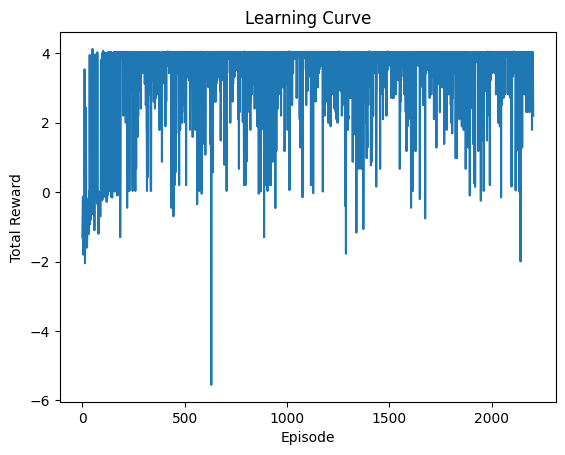

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

print (model.replay_buffer)
## plotting the learning curve
buffer = model.replay_buffer
rewards = buffer.rewards
dones = buffer.dones
episode_rewards = []
current_reward = 0
for r, d in zip(rewards, dones):
    current_reward += r
    if d:
        episode_rewards.append(current_reward)
        current_reward = 0
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Learning Curve")

plt.show()



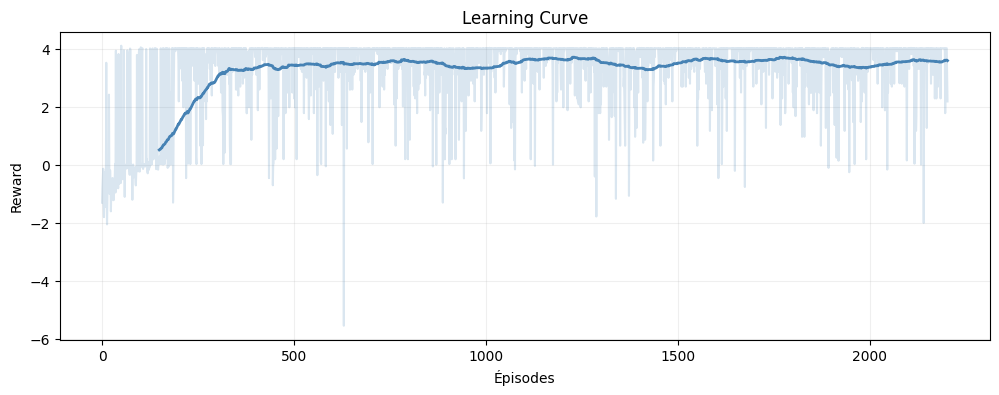

In [23]:
import numpy as np
import matplotlib.pyplot as plt


rewards = buffer.rewards[:buffer.pos].flatten()
dones = buffer.dones[:buffer.pos].flatten()

episode_rewards = []
current_reward = 0
for r, d in zip(rewards, dones):
    current_reward += float(r)
    if d:
        episode_rewards.append(current_reward)
        current_reward = 0

window = 150
smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 4))
plt.plot(episode_rewards, alpha=0.2, color='steelblue')
plt.plot(range(window-1, len(episode_rewards)), smoothed, color='steelblue', linewidth=2)
plt.xlabel("Épisodes")
plt.ylabel("Reward")
plt.title("Learning Curve")
plt.grid(alpha=0.2)
plt.show()

## Max reward episode replay

In [ ]:
max_reward = max(episode_rewards)
idx_maw_reward = episode_rewards.index(max_reward)
max_reward_episode = buffer.observations[idx_maw_reward]

def get_actions_from_episode(model, episode_idx):
    '''Get the sequence of actions taken in a specific episode from the replay buffer, to analyze the agent's behavior during that episode.'''
    buffer = model.replay_buffer
    actions = buffer.actions[:buffer.pos]
    dones = buffer.dones[:buffer.pos]
    
    episodes = []
    current_episode_actions = []
    
    for i in range(len(actions)):
        current_episode_actions.append(int(actions[i][0][0]))
        if dones[i]:
            episodes.append(current_episode_actions)
            current_episode_actions = []
            
    if episode_idx >= len(episodes):
        print(f"Erreur : Le buffer ne contient que {len(episodes)} épisodes complets.")
        return None
        
    return episodes[episode_idx]



def replay_recorded_episode(env, actions):
    '''Replay a recorded episode in the environment step by step, printing the action taken, the reward received, 
    and the total reward accumulated at each step, to visualize the agent's behavior during that episode.'''
    obs, _ = env.reset()
    env.render()
    total_r = 0
    for a in actions:
        obs, r, done, truncated, info = env.step(a)
        total_r += r
        print(f"Action: {a}, Reward: {r}, Total Reward: {total_r}")
        env.render()
        if done: break
    print(f"Total Replay Reward: {total_r}")

best_actions = get_actions_from_episode(model, idx_maw_reward)
if best_actions:
    replay_recorded_episode(env, best_actions)



. . T . S . B . .
C               P
.   v           .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), True, True, True)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 0/400
Action: 5, Reward: -0.002, Total Reward: -0.002

. . T . S . B . .
C               P
.   v           .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), True, True, True)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 1/400
Action: 4, Reward: -0.002, Total Reward: -0.004

. . T . S . B . .
C               P
.   v           .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), True, True, True)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 2

In [20]:
buffer = model.replay_buffer
actions = buffer.actions[:buffer.size()]
unique, counts = np.unique(actions, return_counts=True)
action_counts = dict(zip(unique, counts))
print("Action distribution in replay buffer:", action_counts)

Action distribution in replay buffer: {np.int64(0): np.int64(7056), np.int64(1): np.int64(13691), np.int64(2): np.int64(9751), np.int64(3): np.int64(22246), np.int64(4): np.int64(36366), np.int64(5): np.int64(10890)}


## Model prediction

In [22]:
obs, _ = env.reset()

for _ in range(200):

    action, _ = model.predict(obs, deterministic=True)

    print("action:", action)

    obs, reward, done, truncated, info = env.step(action)
    print("reward:", reward)
    env.render()

    if done:
        break

action: 3
reward: -0.002

. . T . S . B . .
C               P
.     >         .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), True, True, True)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 1/400
action: 3
reward: -0.002

. . T . S . B . .
C               P
.       >       .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), True, True, True)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 2/400
action: 1
reward: -0.002

. . T . S . B . .
C               P
.               .
.       v       V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), True, True, True)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 3/400
action: 4
reward

# Stage 2 : learn to complete a burger

## Training

In [ ]:
from stable_baselines3 import DQN

env_2 = OvercookedKitchen(MY_LAYOUT,stage=2)
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# load the model trained on stage 1 and train on stage 2 to transfer the knowledge
total_timesteps = 300_000
model_2 = DQN.load("model_stage_1", env=env_2, seed=seed, verbose=1, learning_rate=1e-4, buffer_size=1000000, learning_starts=5000, batch_size=64, gamma=0.99, exploration_initial_eps=1.0, exploration_final_eps=0.01, exploration_fraction=0.4, target_update_interval=2000)
model_2.set_env(env_2)

model_2.learn(total_timesteps=total_timesteps, reset_num_timesteps=False, callback=make_early_stopping(threshold=6, window=100))
model_2.save("model_stage_2")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 38.7     |
|    ep_rew_mean      | 3.28     |
|    exploration_rate | 0.371    |
| time/               |          |
|    episodes         | 2208     |
|    fps              | 3320     |
|    time_elapsed     | 0        |
|    total_timesteps  | 101600   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000407 |
|    n_updates        | 25149    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 54.3     |
|    ep_rew_mean      | 2.97     |
|    exploration_rate | 0.361    |
| time/               |          |
|    episodes         | 2212     |
|    fps              | 3774     |
|    time_elapsed     | 0        |
|    t

## Learning curve

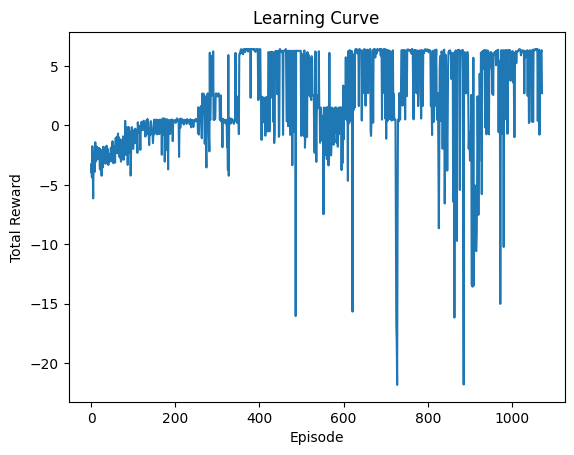

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

print (model_2.replay_buffer)
## plotting the learning curve
buffer = model_2.replay_buffer
rewards = buffer.rewards
dones = buffer.dones
episode_rewards = []
current_reward = 0
for r, d in zip(rewards, dones):
    current_reward += r
    if d:
        episode_rewards.append(current_reward)
        current_reward = 0
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Learning Curve")

plt.show()



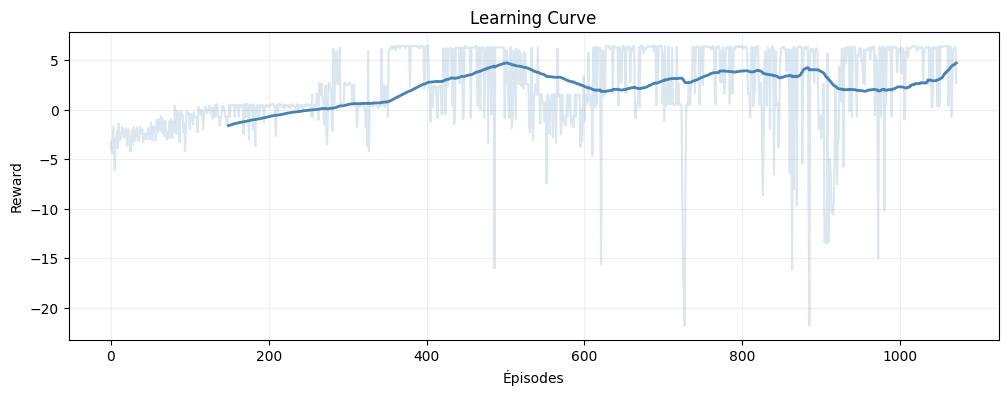

In [67]:
import numpy as np
import matplotlib.pyplot as plt

rewards = buffer.rewards[:buffer.pos].flatten()
dones = buffer.dones[:buffer.pos].flatten()

episode_rewards = []
current_reward = 0
for r, d in zip(rewards, dones):
    current_reward += float(r)
    if d:
        episode_rewards.append(current_reward)
        current_reward = 0

window = 150
smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 4))
plt.plot(episode_rewards, alpha=0.2, color='steelblue')
plt.plot(range(window-1, len(episode_rewards)), smoothed, color='steelblue', linewidth=2)
plt.xlabel("Épisodes")
plt.ylabel("Reward")
plt.title("Learning Curve")
plt.grid(alpha=0.2)
plt.show()

## Max reward episode replay

In [68]:
max_reward = max(episode_rewards)
idx_maw_reward = episode_rewards.index(max_reward)
max_reward_episode = buffer.observations[idx_maw_reward]

def get_actions_from_episode(model, episode_idx):
    buffer = model.replay_buffer
    actions = buffer.actions[:buffer.pos]
    dones = buffer.dones[:buffer.pos]
    
    episodes = []
    current_episode_actions = []
    
    for i in range(len(actions)):
        current_episode_actions.append(int(actions[i][0][0]))
        if dones[i]:
            episodes.append(current_episode_actions)
            current_episode_actions = []
            
    if episode_idx >= len(episodes):
        print(f"Erreur : Le buffer ne contient que {len(episodes)} épisodes complets.")
        return None
        
    return episodes[episode_idx]




def replay_recorded_episode(env, actions):
    obs, _ = env.reset()
    env.render()
    total_r = 0
    for a in actions:
        obs, r, done, truncated, info = env.step(a)
        total_r += r
        print(f"Action: {a}, Reward: {r}, Total Reward: {total_r}")
        env.render()
        if done: break
    print(f"Total Replay Reward: {total_r}")

best_actions = get_actions_from_episode(model_2, idx_maw_reward)
if best_actions:
    replay_recorded_episode(env_2, best_actions)



. . T . S . B . .
C               P
.   v           .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((0, 1), 'chopped_tomato'), ((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 1 active
  order_0: burger (wait: 0)
Steps: 0/400
Action: 3, Reward: 0.009428571428571429, Total Reward: 0.009428571428571429

. . T . S . B . .
C               P
.     >         .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((0, 1), 'chopped_tomato'), ((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 1 active
  order_0: burger (wait: 1)
Steps: 1/400
Action: 3, Reward: 0.010857142857142857, Total Reward: 0.020285714285714285

. . T . S . B . .
C               P
.       >       .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'ready

## Model prediction

In [69]:
obs, _ = env_2.reset()

for _ in range(200):

    action, _ = model_2.predict(obs, deterministic=True)

    print("action:", action)

    obs, reward, done, truncated, info = env_2.step(action)
    
    print("reward:", reward)
    env_2.render()

    if done:
        break

action: 3
reward: 0.009428571428571429

. . T . S . B . .
C               P
.     >         .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((0, 1), 'chopped_tomato'), ((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 1 active
  order_0: burger (wait: 1)
Steps: 1/400
action: 0
reward: 0.010857142857142857

. . T . S . B . .
C     ^         P
.               .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((0, 1), 'chopped_tomato'), ((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 1 active
  order_0: burger (wait: 2)
Steps: 2/400
action: 3
reward: 0.012285714285714287

. . T . S . B . .
C       >       P
.               .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, Fal

# Stage 3 - learn to chop a tomato

## Training

In [ ]:
from stable_baselines3 import DQN
import random
import numpy as np
import torch

env_3 = OvercookedKitchen(MY_LAYOUT,stage=3)
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

total_timesteps = 1_000_000
model_3 = DQN.load("model_stage_2", env=env_3, seed=seed, verbose=1, learning_rate=1e-4, buffer_size=10000000, learning_starts=10000, batch_size=64, gamma=0.99, exploration_initial_eps=1.0, exploration_final_eps=0.01, exploration_fraction=0.7, target_update_interval=2000)
model_3.set_env(env_3)

model_3.learn(total_timesteps=total_timesteps, reset_num_timesteps=False, callback=make_early_stopping(threshold=7, window=80))
model_3.save("model_stage_3")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 2.88GB > 1.62GB
  warnings.warn(


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 204      |
|    ep_rew_mean      | 4.3      |
|    exploration_rate | 0.592    |
| time/               |          |
|    episodes         | 3280     |
|    fps              | 4405     |
|    time_elapsed     | 0        |
|    total_timesteps  | 404000   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00334  |
|    n_updates        | 100749   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 237      |
|    ep_rew_mean      | 3.48     |
|    exploration_rate | 0.588    |
| time/               |          |
|    episodes         | 3284     |
|    fps              | 4529     |
|    time_elapsed     | 1        |
|    total_timesteps  | 408000   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00175  |
|    n_updates      

## Learning curve

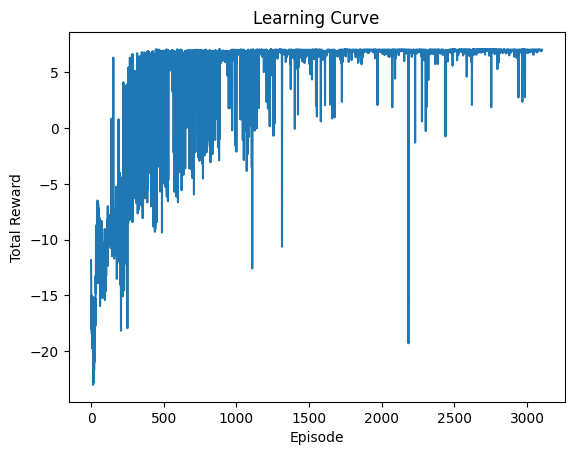

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

print (model_3.replay_buffer)
buffer = model_3.replay_buffer
rewards = buffer.rewards
dones = buffer.dones
episode_rewards = []
current_reward = 0
for r, d in zip(rewards, dones):
    current_reward += r
    if d:
        episode_rewards.append(current_reward)
        current_reward = 0
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Learning Curve")

plt.show()



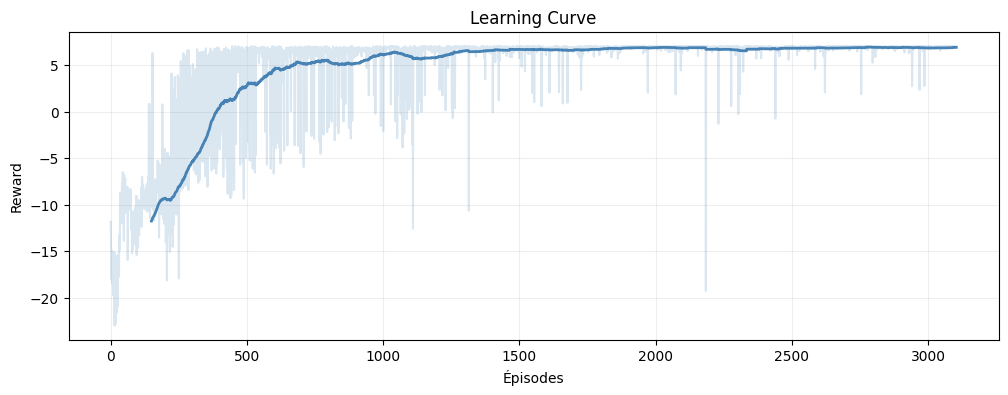

In [106]:
import numpy as np
import matplotlib.pyplot as plt

rewards = buffer.rewards[:buffer.pos].flatten()
dones = buffer.dones[:buffer.pos].flatten()

episode_rewards = []
current_reward = 0
for r, d in zip(rewards, dones):
    current_reward += float(r)
    if d:
        episode_rewards.append(current_reward)
        current_reward = 0

window = 150
smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 4))
plt.plot(episode_rewards, alpha=0.2, color='steelblue')
plt.plot(range(window-1, len(episode_rewards)), smoothed, color='steelblue', linewidth=2)
plt.xlabel("Épisodes")
plt.ylabel("Reward")
plt.title("Learning Curve")
plt.grid(alpha=0.2)
plt.show()

## Max reward episode replay

In [104]:
max_reward = max(episode_rewards)
idx_maw_reward = episode_rewards.index(max_reward)
max_reward_episode = buffer.observations[idx_maw_reward]

def get_actions_from_episode(model, episode_idx):
    buffer = model.replay_buffer
    actions = buffer.actions[:buffer.pos]
    dones = buffer.dones[:buffer.pos]
    
    episodes = []
    current_episode_actions = []
    
    for i in range(len(actions)):
        current_episode_actions.append(int(actions[i][0][0]))
        if dones[i]:
            episodes.append(current_episode_actions)
            current_episode_actions = []
            
    if episode_idx >= len(episodes):
        print(f"Erreur : Le buffer ne contient que {len(episodes)} épisodes complets.")
        return None
        
    return episodes[episode_idx]

def replay_recorded_episode(env, actions):
    obs, _ = env.reset()
    env.render()
    total_r = 0
    for a in actions:
        obs, r, done, truncated, info = env.step(a)
        total_r += r
        print(f"Action: {a}, Reward: {r}, Total Reward: {total_r}")
        env.render()
        if done: break
    print(f"Total Replay Reward: {total_r}")

best_actions = get_actions_from_episode(model_3, idx_maw_reward)
if best_actions:
    replay_recorded_episode(env_3, best_actions)



. . T . S . B . .
C               P
.   v           .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 1 active
  order_0: burger (wait: 0)
Steps: 0/1000
Action: 0, Reward: 0.009428571428571429, Total Reward: 0.009428571428571429

. . T . S . B . .
C   ^           P
.               .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 1 active
  order_0: burger (wait: 1)
Steps: 1/1000
Action: 4, Reward: 0.498, Total Reward: 0.5074285714285715

. . T . S . B . .
C   ^           P
.               .
.               V
. . . . D . . . .
Hand : tomato
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, False, False)]
Chopping boards : [('c

## Model Prediciton

In [105]:
obs, _ = env_3.reset()

for _ in range(1000):

    action, _ = model_3.predict(obs, deterministic=True)

    print("action:", action)

    obs, reward, done, truncated, info = env_3.step(action)
    print("reward:", reward)
    env_3.render()

    if done:
        break

action: 0
reward: 0.009428571428571429

. . T . S . B . .
C   ^           P
.               .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 1 active
  order_0: burger (wait: 1)
Steps: 1/1000
action: 4
reward: 0.498

. . T . S . B . .
C   ^           P
.               .
.               V
. . . . D . . . .
Hand : tomato
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 1 active
  order_0: burger (wait: 2)
Steps: 2/1000
action: 2
reward: -0.002

. . T . S . B . .
C <             P
.               .
.               V
. . . . D . . . .
Hand : tomato
Pans : [((8, 1), 'ready', 5)]
Dishes : [((4, 4), True, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8,

# Stage 5 Full pipeline

## Training

In [ ]:
from stable_baselines3 import DQN
import random
import numpy as np
import torch

env_final = OvercookedKitchen(MY_LAYOUT,stage=4)
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

total_timesteps = 3_000_000
model_final = DQN.load("model_stage_3", env=env_final, seed=seed, verbose=1, learning_rate=1e-4, buffer_size=100000000, learning_starts=10000, batch_size=64, gamma=0.99, exploration_initial_eps=1.0, exploration_final_eps=0.01, exploration_fraction=0.5, target_update_interval=2000)
model_final.set_env(env_final)

model_final.learn(total_timesteps=total_timesteps, reset_num_timesteps=False, callback=make_early_stopping(threshold=7, window=100))
model_final.save("model_final")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 28.80GB > 1.58GB
  warnings.warn(


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 97.7     |
|    ep_rew_mean      | 6.29     |
|    exploration_rate | 0.475    |
| time/               |          |
|    episodes         | 6384     |
|    fps              | 4606     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1079952  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0129   |
|    n_updates        | 269736   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 134      |
|    ep_rew_mean      | 5.53     |
|    exploration_rate | 0.473    |
| time/               |          |
|    episodes         | 6388     |
|    fps              | 4316     |
|    time_elapsed     | 1        |
|    total_timesteps  | 1083952  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0094   |
|    n_updates      

## Learning curve

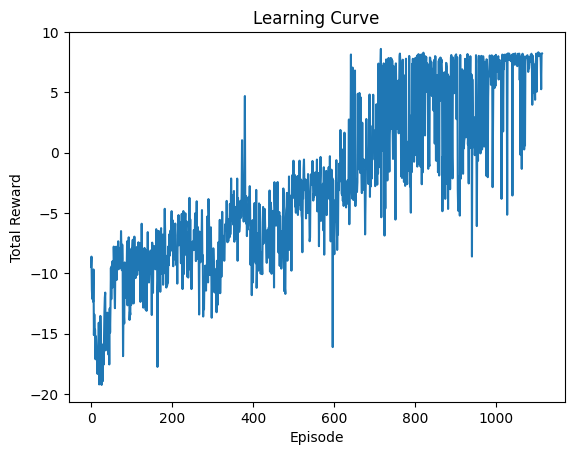

In [130]:
import pandas as pd
import matplotlib.pyplot as plt

print (model_final.replay_buffer)
buffer = model_final.replay_buffer
rewards = buffer.rewards
dones = buffer.dones
episode_rewards = []
current_reward = 0
for r, d in zip(rewards, dones):
    current_reward += r
    if d:
        episode_rewards.append(current_reward)
        current_reward = 0
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Learning Curve")

plt.show()

Smoothed learning curve

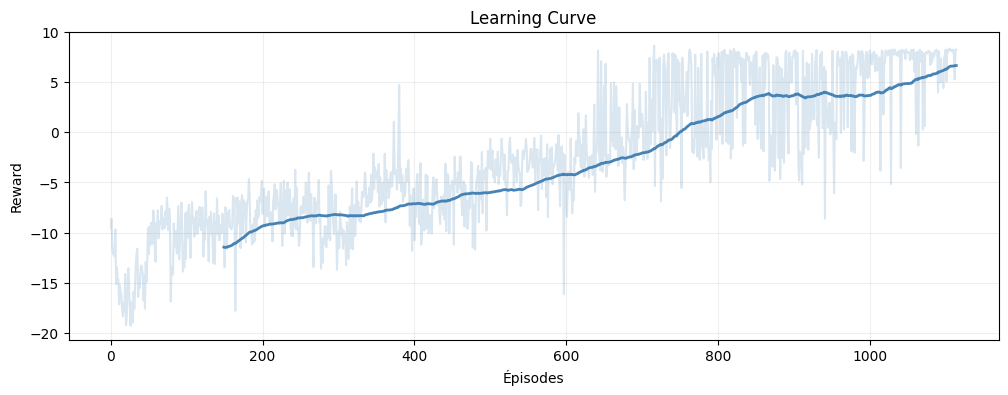

In [131]:
import numpy as np
import matplotlib.pyplot as plt


buffer = model_final.replay_buffer
rewards = buffer.rewards[:buffer.pos].flatten()
dones = buffer.dones[:buffer.pos].flatten()

episode_rewards = []
current_reward = 0
for r, d in zip(rewards, dones):
    current_reward += float(r)
    if d:
        episode_rewards.append(current_reward)
        current_reward = 0

window = 150
smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 4))
plt.plot(episode_rewards, alpha=0.2, color='steelblue')
plt.plot(range(window-1, len(episode_rewards)), smoothed, color='steelblue', linewidth=2)
plt.xlabel("Épisodes")
plt.ylabel("Reward")
plt.title("Learning Curve")
plt.grid(alpha=0.2)
plt.show()

## Max reward episode replay

In [132]:
max_reward = max(episode_rewards)
idx_maw_reward = episode_rewards.index(max_reward)
max_reward_episode = buffer.observations[idx_maw_reward]

def get_actions_from_episode(model, episode_idx):
    buffer = model.replay_buffer
    actions = buffer.actions[:buffer.pos]
    dones = buffer.dones[:buffer.pos]
    
    episodes = []
    current_episode_actions = []
    
    for i in range(len(actions)):
        current_episode_actions.append(int(actions[i][0][0]))
        if dones[i]:
            episodes.append(current_episode_actions)
            current_episode_actions = []
            
    if episode_idx >= len(episodes):
        print(f"Erreur : Le buffer ne contient que {len(episodes)} épisodes complets.")
        return None
        
    return episodes[episode_idx]



def replay_recorded_episode(env, actions):
    obs, _ = env.reset()
    env.render()
    total_r = 0
    for a in actions:
        obs, r, done, truncated, info = env.step(a)
        total_r += r
        print(f"Action: {a}, Reward: {r}, Total Reward: {total_r}")
        env.render()
        if done: break
    print(f"Total Replay Reward: {total_r}")

best_actions = get_actions_from_episode(model_final, idx_maw_reward)
if best_actions:
    replay_recorded_episode(env_final, best_actions)



. . T . S . B . .
C               P
.   v           .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 0/1000
Action: 3, Reward: 0.010857142857142857, Total Reward: 0.010857142857142857

. . T . S . B . .
C               P
.     >         .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 1/1000
Action: 3, Reward: 0.012285714285714287, Total Reward: 0.023142857142857146

. . T . S . B . .
C               P
.       >       .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters 

## Model Prediciton

In [ ]:
from stable_baselines3 import DQN
env_final = OvercookedKitchen(MY_LAYOUT,stage=4)
model_final = DQN.load("model_final", env=env_final)
obs, _ = env_final.reset()

for _ in range(1000):

    action, _ = model_final.predict(obs, deterministic=True)

    print("action:", action)

    obs, reward, done, truncated, info = env_final.step(action)
    print("reward:", reward)
    env_final.render()

    if done:
        break

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
action: 3
reward: 0.010857142857142857

. . T . S . B . .
C               P
.     >         .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 1/1000
action: 3
reward: 0.012285714285714287

. . T . S . B . .
C               P
.       >       .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 2/1000
action: 3
reward: 0.013714285714285715

. . T . S . B . .
C               P
.         >     .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : 

/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 28.80GB > 1.70GB
  warnings.warn(


# Trained agent final visualisations

## Render

In [ ]:
import pygame
import sys


TILE_SIZE = 80

COLORS = {
    'floor':   (245, 235, 220),
    'counter': (180, 140, 100),
    'bg':      (120, 80,  50),
}

class PygameRenderer:
    '''Renderer for the OvercookedKitchen environment using Pygame, responsible for visualizing the game state'''
    def __init__(self, env, asset_dir="./assets"):
        if not pygame.get_init():
            pygame.init()
        self.env = env
        self.tile = TILE_SIZE
        self.width  = env.width  * TILE_SIZE
        self.height = env.height * TILE_SIZE
        self.screen = pygame.display.set_mode((self.width, self.height))
        pygame.display.set_caption("Overcooked RL")
        self.clock = pygame.time.Clock()
        self.font = pygame.font.SysFont("Arial", 14, bold=True)

        def load(name):
            try:
                img = pygame.image.load(f"{asset_dir}/{name}.png").convert_alpha()
                return pygame.transform.scale(img, (TILE_SIZE, TILE_SIZE))
            except:
                # Fallback : carré coloré si image manquante
                surf = pygame.Surface((TILE_SIZE, TILE_SIZE), pygame.SRCALPHA)
                surf.fill((200, 200, 200, 180))
                text = self.font.render(name[:3], True, (0,0,0))
                surf.blit(text, (5, 5))
                return surf

        self.imgs = {
            'chef_up':         load("chef_up"),
            'chef_down':       load("chef_down"),
            'chef_left':       load("chef_left"),
            'chef_right':      load("chef_right"),
            'tomato':          load("tomato"),
            'steak':           load("steak"),
            'bread':           load("bread"),
            'chopped_tomato':  load("chopped_tomato"),
            'pan_empty':       load("pan_empty"),
            'pan_cooking':     load("pan_cooking"),
            'pan_ready':       load("pan_ready"),
            'dish':            load("dish"),
            'burger':          load("burger"),
            'counter':         load("counter"),
            'floor':           load("floor"),
            'delivery':        load("delivery"),
            'chop_board':      load("chop_board"),
            'dispenser_T':     load("dispenser_tomato"),
            'dispenser_S':     load("dispenser_steak"),
            'dispenser_B':     load("dispenser_bread"),
            'pan_0':          load("pan_0"),
            'empty_stove':    load("empty_stove"),
        }

    def notify(self, text, color=(255, 255, 255), duration=40):
        self._notif = (text, color, duration)

    def render(self, fps=8):
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                sys.exit()

        env = self.env
        self.screen.fill(COLORS['bg'])

        for y, row in enumerate(env.layout):
            for x, tile in enumerate(row):
                rx, ry = x * self.tile, y * self.tile

                if tile == ' ':
                    self.screen.blit(self.imgs['floor'], (rx, ry))
                elif tile in ('.', 'P', 'C', 'D', 'T', 'S', 'B', 'V', '#', 'X'):
                    self.screen.blit(self.imgs['counter'], (rx, ry))

                if tile == 'V':
                    self.screen.blit(self.imgs['delivery'], (rx, ry))
                elif tile == 'C':
                    self.screen.blit(self.imgs['chop_board'], (rx, ry))
                elif tile == 'T':
                    self.screen.blit(self.imgs['dispenser_T'], (rx, ry))
                    small_tomato = pygame.transform.scale(self.imgs['tomato'], (self.tile // 2, self.tile // 2))
                    self.screen.blit(small_tomato, (rx + self.tile // 4, ry + self.tile // 8))
                elif tile == 'S':
                    self.screen.blit(self.imgs['dispenser_S'], (rx, ry))
                elif tile == 'B':
                    self.screen.blit(self.imgs['dispenser_B'], (rx, ry))

                if tile == 'P':
                    pan_id = f"pan_{env.cooking_surfaces.index((x,y))}"
                    status = env.pans_state[pan_id]['status']
                    if status == 'empty' or env.pans_state[pan_id]['location'] != (x,y):
                        self.screen.blit(self.imgs['pan_empty'], (rx, ry))
                    elif status == 'cooking':
                        self.screen.blit(self.imgs['pan_cooking'], (rx, ry))
                        timer_val = env.pans_state[pan_id]['timer']
                        timer_surf = self.font.render(f"{timer_val}/{env.TIME_TO_COOK}", True, (255, 255, 255))
                        self.screen.blit(timer_surf, (rx + 2, ry + self.tile - 18))
                    else:
                        self.screen.blit(self.imgs['pan_ready'], (rx, ry))
                        timer_val = env.pans_state[pan_id]['timer']
                        timer_surf = self.font.render(f"{timer_val}/{env.TIME_TO_COOK}", True, (255, 255, 255))
                        self.screen.blit(timer_surf, (rx + 2, ry + self.tile - 18))
                    

                if tile == 'D':
                    self.screen.blit(self.imgs['dish'], (rx, ry))
                    dish = env.dishes.get('dish_0')
                    if dish:
                        items = []
                        if dish['bread'] and dish['tomato'] and dish['steak']:
                            items = ['burger']
                        else:
                            if dish['bread']:    items.append('bread')
                            if dish['tomato']:   items.append('chopped_tomato')
                            if dish['steak']:    items.append('pan_ready')
                        
                        offset_x = 0
                        for item in items:
                            if item in self.imgs:
                                size = self.tile // len(items) if len(items) > 1 else self.tile // 2
                                small = pygame.transform.scale(self.imgs[item], (size, size))
                                self.screen.blit(small, (rx + offset_x, ry + self.tile // 2))
                                offset_x += size

                obj = env.objects_on_counters.get((x, y))
                if obj and 'pan' not in str(obj) and 'dish' not in str(obj):
                    img_key = obj if obj in self.imgs else None
                    if img_key:
                        small = pygame.transform.scale(self.imgs[img_key],
                                                       (self.tile//2, self.tile//2))
                        self.screen.blit(small, (rx + self.tile//4, ry + self.tile//4))
                if obj and 'pan' in str(obj) and (x, y) not in env.cooking_surfaces:
                    pan_id = obj
                    status = env.pans_state.get(pan_id, {}).get('status', 'empty')
                    pan_img_key = 'pan_0'
                    small = pygame.transform.scale(self.imgs[pan_img_key],
                                                (self.tile//2, self.tile//2))
                    self.screen.blit(small, (rx + self.tile//4, ry + self.tile//4))

        ax, ay = env.agent_pos
        dir_map = {(0,-1): 'up', (0,1): 'down', (-1,0): 'left', (1,0): 'right'}
        direction = dir_map.get(env.agent_dir, 'down')
        self.screen.blit(self.imgs[f'chef_{direction}'],
                         (ax * self.tile, ay * self.tile))

        if env.held_obj:
            held_key = env.held_obj
            if 'pan' in str(held_key):
                status = env.pans_state[held_key]['status']
                held_key = f"pan_{status}"
                if status == 'empty':
                    held_key = 'pan_0'
            if held_key == 'full_burger':
                held_key = 'burger'
            if held_key in self.imgs:
                small = pygame.transform.scale(self.imgs[held_key],
                                               (self.tile//2, self.tile//2))
                self.screen.blit(small,
                                 (ax * self.tile + self.tile//2,
                                  ay * self.tile - self.tile//4))

        hud_y = 4
        infos = [
            f"Steps: {env.step_count}/{env.MAX_STEPS}",
            f"Hand: {env.held_obj or 'empty'}",
            f"Dish: {'B' if env.dishes['dish_0']['bread'] else '·'}"
                  f"{'T' if env.dishes['dish_0']['tomato'] else '·'}"
                  f"{'S' if env.dishes['dish_0']['steak'] else '·'}",
            f"Orders: {', '.join(o['recipe'] for o in env.orders.values() if o['recipe'] != 'empty') if env.orders else 'No orders'}"
        ]
        for info in infos:
            surf = self.font.render(info, True, (0, 0, 0))
            self.screen.blit(surf, (6, hud_y))
            hud_y += 18

        if hasattr(self, '_notif') and self._notif:
            text, color, timer = self._notif
            surf = pygame.font.SysFont("Arial", 22, bold=True).render(text, True, color)
            self.screen.blit(surf, (self.width // 2 - surf.get_width() // 2,
                                    self.height // 2 - 20))
            self._notif = (text, color, timer - 1) if timer > 1 else None

        pygame.display.flip()
        self.clock.tick(fps)

In [ ]:
from stable_baselines3 import DQN
env_final = OvercookedKitchen(MY_LAYOUT,stage=4)
model_final = DQN.load("model_final_new", env=env_final)
renderer = PygameRenderer(env_final, asset_dir="./assets")

obs, _ = env_final.reset()
done = trunc = False

try:
    while not (done or trunc):
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                raise KeyboardInterrupt
            if event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE:
                raise KeyboardInterrupt

        prev_held = env_final.held_obj
        prev_pan_status = env_final.pans_state['pan_0']['status']
        action, _ = model_final.predict(obs, deterministic=True)
        obs, reward, done, trunc, _ = env_final.step(int(action))
        pan = env_final.pans_state['pan_0']
        if (prev_pan_status in ('cooking', 'ready')
            and pan['status'] == 'empty'
            and pan['location'] in env_final.cooking_surfaces
            and not done):
            renderer.notify("Steak burned !", color=(255, 80, 50), duration=3)

        if done and prev_held == "full_burger":
            renderer.notify("Burger delivered !", color=(50, 255, 100), duration=60)

        renderer.render(fps=4)

        if done or trunc:
            renderer.render(fps=1)
            break

except KeyboardInterrupt:
    pass
finally:
    pygame.quit()


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 28.80GB > 1.67GB
  warnings.warn(


: 

# Results plots

## Success rate vs random exploration

In [ ]:
from stable_baselines3 import DQN
import numpy as np
def compute_success_rate(model, layout, stage, n_episodes=100, eps=0.05):
    '''Compute the success rate of the trained model on a given stage and layout, 
    by running multiple episodes and checking how many times the agent successfully completes the task, with an epsilon for random actions to test robustness.'''
    successes = 0
    for _ in range(n_episodes):
        env = OvercookedKitchen(layout, stage=stage)
        obs, _ = env.reset()
        done = trunc = False
        while not (done or trunc):
            if np.random.random() < eps:
                action = env.action_space.sample()
            else:
                action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, trunc, _ = env.step(int(action))
        if done:
            successes += 1
    return successes / n_episodes * 100

results = []
stage = 4
for eps in range(0,100,5):
    eps = eps / 100
    model_path = "model_final_new"
    env = OvercookedKitchen(MY_LAYOUT, stage=stage)
    model = DQN.load(model_path, env=env)
    rate = compute_success_rate(model, MY_LAYOUT, stage, eps=eps)
    results.append((eps, rate))


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 28.80GB > 1.82GB
  warnings.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 28.80GB > 1.79GB
  warnings.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


...

/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 28.80GB > 1.83GB
  warnings.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 28.80GB > 1.80GB
  warnings.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 28.80GB > 1.81GB
  warnings.warn(


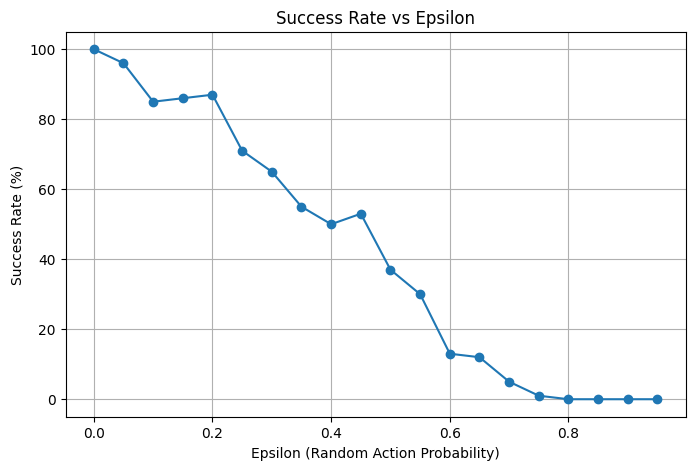

In [8]:
from matplotlib import pyplot as plt
eps_values, success_rates = zip(*results)
plt.figure(figsize=(8, 5))
plt.plot(eps_values, success_rates, marker='o')
plt.title("Success Rate vs Epsilon")
plt.xlabel("Epsilon (Random Action Probability)")
plt.ylabel("Success Rate (%)")
plt.grid()
plt.show()

## Success rate and average steps by stage evaluated with the final model

In [ ]:

def compute_success_rate(model, layout, stage, n_episodes=100, eps=0.05):
    '''Compute the success rate of the trained model on a given stage and layout, 
    by running multiple episodes and checking how many times the agent successfully completes the task, with an epsilon for random actions to test robustness.'''
    successes = 0
    for _ in range(n_episodes):
        env = OvercookedKitchen(layout, stage=stage)
        obs, _ = env.reset()
        done = trunc = False
        while not (done or trunc):
            if np.random.random() < eps:
                action = env.action_space.sample()
            else:
                action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, trunc, _ = env.step(int(action))
        if done:
            successes += 1
    return successes / n_episodes * 100

model_final = DQN.load("model_final", env=OvercookedKitchen(MY_LAYOUT, stage=4))
for stage in range(1, 5):
    rate = compute_success_rate(model_final, MY_LAYOUT, stage, n_episodes=100)
    print(f"Stage {stage}: {rate:.1f}%")


def compute_avg_steps(model, layout, stage, n_episodes=100):
    '''Compute the average number of steps taken by the trained model to successfully complete the task on a given stage and layout, 
    by running multiple episodes and averaging the step count for successful completions.'''
    steps_list = []
    for _ in range(n_episodes):
        env = OvercookedKitchen(layout, stage=stage)
        obs, _ = env.reset()
        done = trunc = False
        while not (done or trunc):
            action, _ = model.predict(obs, deterministic=False)
            obs, reward, done, trunc, _ = env.step(int(action))
        if done:
            steps_list.append(env.step_count)
    return np.mean(steps_list) if steps_list else None

model_final = DQN.load("model_final_new", env=OvercookedKitchen(MY_LAYOUT, stage=4))
for stage in range(1, 5):
    avg_steps = compute_avg_steps(model_final, MY_LAYOUT, stage, n_episodes=100)
    print(f"Stage {stage}: Average Steps on Success: {avg_steps:.1f}")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 2.88GB > 1.75GB
  warnings.warn(


Stage 1: 17.0%
Stage 2: 1.0%
Stage 3: 91.0%
Stage 4: 90.0%
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 28.80GB > 1.72GB
  warnings.warn(


Stage 1: Average Steps on Success: 281.1
Stage 2: Average Steps on Success: 252.8
Stage 3: Average Steps on Success: 147.4
Stage 4: Average Steps on Success: 73.5


## Model robustness test : Success rate from different starting positions

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Start (1, 1) | Success: 90.0% | Avg steps: 63


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 28.80GB > 1.75GB
  warnings.warn(


Start (2, 1) | Success: 95.0% | Avg steps: 73
Start (3, 1) | Success: 90.0% | Avg steps: 64
Start (4, 1) | Success: 80.0% | Avg steps: 72
Start (5, 1) | Success: 90.0% | Avg steps: 78
Start (6, 1) | Success: 90.0% | Avg steps: 54
Start (7, 1) | Success: 90.0% | Avg steps: 72
Start (1, 2) | Success: 95.0% | Avg steps: 150
Start (2, 2) | Success: 90.0% | Avg steps: 72
Start (3, 2) | Success: 95.0% | Avg steps: 148
Start (4, 2) | Success: 90.0% | Avg steps: 73
Start (5, 2) | Success: 90.0% | Avg steps: 68
Start (6, 2) | Success: 95.0% | Avg steps: 54
Start (7, 2) | Success: 100.0% | Avg steps: 72
Start (1, 3) | Success: 95.0% | Avg steps: 88
Start (2, 3) | Success: 95.0% | Avg steps: 62
Start (3, 3) | Success: 100.0% | Avg steps: 82
Start (4, 3) | Success: 100.0% | Avg steps: 60
Start (5, 3) | Success: 90.0% | Avg steps: 100
Start (6, 3) | Success: 100.0% | Avg steps: 122
Start (7, 3) | Success: 95.0% | Avg steps: 87


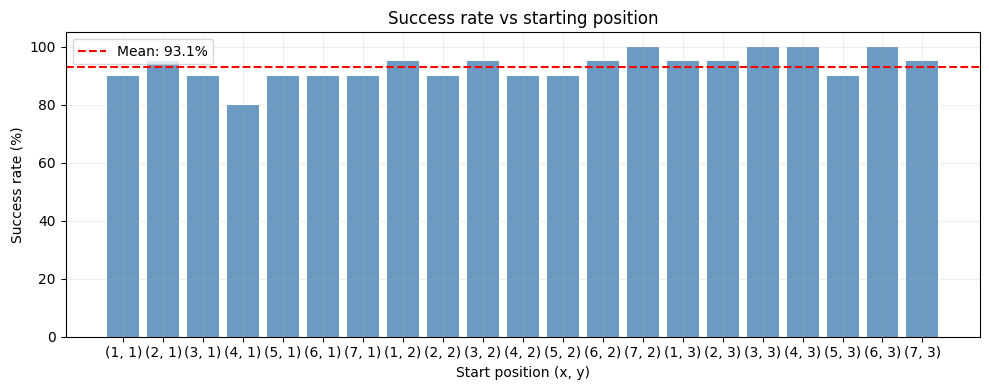

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN
model_final = DQN.load("model_final_new", env=OvercookedKitchen(MY_LAYOUT, stage=4))
def test_from_multiple_starts(model, layout, stage=6, n_positions=10, n_episodes_per_pos=20, epsilon=0.05):
    """
    Test the trained model from multiple random starting positions in the given layout and stage, to evaluate its robustness and generalization across different initial conditions.
    """
    # Take all free positions in the layout
    free_positions = [
        (x, y)
        for y, row in enumerate(layout)
        for x, tile in enumerate(row)
        if tile == ' '
    ]
    test_positions = free_positions[:n_positions] if len(free_positions) >= n_positions \
                    else free_positions
    
    results = {}
    
    for start_pos in test_positions:
        successes = 0
        avg_steps = []
        
        for _ in range(n_episodes_per_pos):
            env = OvercookedKitchen(layout, stage=stage)
            obs, _ = env.reset()
            
            # Force the agent's starting position to the test position
            env.agent_pos = start_pos
            obs = env._get_obs() 
            
            done = trunc = False
            while not (done or trunc):
                if np.random.random() < epsilon:
                    action = env.action_space.sample()
                else:
                    action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, trunc, _ = env.step(int(action))
            
            if done:
                successes += 1
                avg_steps.append(env.step_count)
        
        success_rate = successes / n_episodes_per_pos * 100
        mean_steps = np.mean(avg_steps) if avg_steps else None
        results[start_pos] = {
            'success_rate': success_rate,
            'avg_steps': mean_steps
        }
        print(f"Start {start_pos} | Success: {success_rate:.1f}% | "
              f"Avg steps: {mean_steps:.0f}" if mean_steps else
              f"Start {start_pos} | Success: {success_rate:.1f}% | Never succeeded")
    
    return results

# Utilization
results = test_from_multiple_starts(
    model=model_final,
    layout=MY_LAYOUT,
    stage=6,
    n_positions=21,
    n_episodes_per_pos=20,
    epsilon=0.05
)

# Visualisation
import matplotlib.pyplot as plt

positions = [str(p) for p in results.keys()]
rates = [v['success_rate'] for v in results.values()]

plt.figure(figsize=(10, 4))
plt.bar(positions, rates, color='steelblue', alpha=0.8)
plt.axhline(np.mean(rates), color='red', linestyle='--', label=f'Mean: {np.mean(rates):.1f}%')
plt.xlabel("Start position (x, y)")
plt.ylabel("Success rate (%)")
plt.title("Success rate vs starting position")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Without curriculum

## Training

In [11]:
from stable_baselines3 import DQN
import random
import numpy as np
import torch

env_final = OvercookedKitchen(MY_LAYOUT,stage=4)
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

total_timesteps = 4_000_000

model_final_without_curriculum = DQN(
    "MlpPolicy",
    env_final,
    seed=seed,
    verbose=1,
    learning_rate=1e-4,
    buffer_size=10000000,
    learning_starts=10000,
    batch_size=64,
    gamma=0.99,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.01,
    exploration_fraction=0.5,
    target_update_interval=2000,
)
model_final_without_curriculum.learn(total_timesteps=total_timesteps, reset_num_timesteps=False, callback=make_early_stopping(threshold=7.5, window=100))
model_final_without_curriculum.save("model_final_without_curriculum")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | -13.1    |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 29920    |
|    time_elapsed     | 0        |
|    total_timesteps  | 4000     |
----------------------------------


/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 2.88GB > 2.16GB
  warnings.warn(


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | -14.3    |
|    exploration_rate | 0.996    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 31533    |
|    time_elapsed     | 0        |
|    total_timesteps  | 8000     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | -14.6    |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 13677    |
|    time_elapsed     | 0        |
|    total_timesteps  | 12000    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000401 |
|    n_updates        | 499      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean    

## Learning Curve

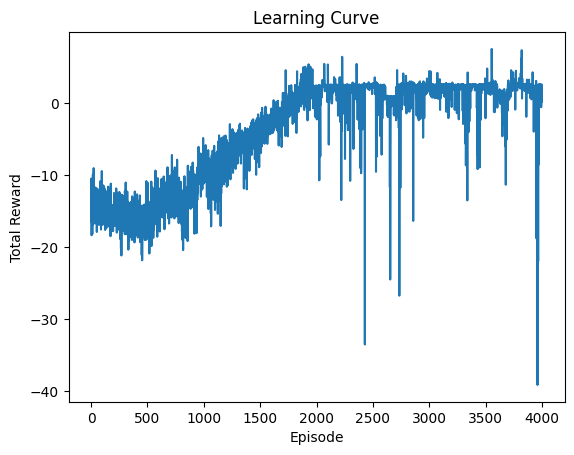

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

print (model_final_without_curriculum.replay_buffer)
buffer = model_final_without_curriculum.replay_buffer
rewards = buffer.rewards
dones = buffer.dones
episode_rewards = []
current_reward = 0
for r, d in zip(rewards, dones):
    current_reward += r
    if d:
        episode_rewards.append(current_reward)
        current_reward = 0
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Learning Curve")

plt.show()

## Max reward episode replay

In [13]:
max_reward = max(episode_rewards)
idx_maw_reward = episode_rewards.index(max_reward)
max_reward_episode = buffer.observations[idx_maw_reward]

def get_actions_from_episode(model, episode_idx):
    buffer = model.replay_buffer
    actions = buffer.actions[:buffer.pos]
    dones = buffer.dones[:buffer.pos]
    
    episodes = []
    current_episode_actions = []
    
    for i in range(len(actions)):
        current_episode_actions.append(int(actions[i][0][0]))
        if dones[i]:
            episodes.append(current_episode_actions)
            current_episode_actions = []
            
    if episode_idx >= len(episodes):
        print(f"Erreur : Le buffer ne contient que {len(episodes)} épisodes complets.")
        return None
        
    return episodes[episode_idx]



def replay_recorded_episode(env, actions):
    obs, _ = env.reset()
    env.render()
    total_r = 0
    for a in actions:
        obs, r, done, truncated, info = env.step(a)
        total_r += r
        print(f"Action: {a}, Reward: {r}, Total Reward: {total_r}")
        env.render()
        if done: break
    print(f"Total Replay Reward: {total_r}")

best_actions = get_actions_from_episode(model_final_without_curriculum, idx_maw_reward)
if best_actions:
    replay_recorded_episode(env_final, best_actions)



. . T . S . B . .
C               P
.   v           .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 0/1000
Action: 3, Reward: 0.010857142857142857, Total Reward: 0.010857142857142857

. . T . S . B . .
C               P
.     >         .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 1/1000
Action: 3, Reward: 0.012285714285714287, Total Reward: 0.023142857142857146

. . T . S . B . .
C               P
.       >       .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters 

## Model prediction

In [14]:
from stable_baselines3 import DQN
env_final = OvercookedKitchen(MY_LAYOUT,stage=4)
model_final = DQN.load("model_final_without_curriculum", env=env_final)
obs, _ = env_final.reset()

for _ in range(1000):

    action, _ = model_final_without_curriculum.predict(obs, deterministic=True)

    print("action:", action)

    obs, reward, done, truncated, info = env_final.step(action)
    print("reward:", reward)
    env_final.render()

    if done:
        break

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
action: 3
reward: 0.010857142857142857

. . T . S . B . .
C               P
.     >         .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 1/1000
action: 3
reward: 0.012285714285714287

. . T . S . B . .
C               P
.       >       .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 2/1000
action: 3
reward: 0.013714285714285715

. . T . S . B . .
C               P
.         >     .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : 

/Users/mathildebodet/Desktop/centrale/3A/RL/WayTooCooked/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 2.88GB > 1.58GB
  warnings.warn(
